In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy 
from scipy.stats import gaussian_kde
from scipy.stats import binned_statistic
from scipy.stats import median_abs_deviation
import astropy.units as u
from astropy.constants import M_sun
from astropy.constants import c
from astropy.constants import L_sun
from astropy.constants import G
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import L_sun
import utils as util

L_sun_eps = L_sun.cgs.value

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/beegfs/general/kprofit/summer_proj/py3-venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/beegfs/general/kprofit/summer_proj/py3-venv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/beegfs/general/kprofit/summer_proj/py3-venv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/beegfs/general/kprofit/summer_proj/py3-venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/beegfs/general/kprofit/summer_proj/py3-venv/lib64/python3.9/site-

In [2]:
UnitLength_in_cm = 3.08568e18
UnitMass_in_g = 4.62681e+35
UnitVelocity_in_cm_per_s = 1e5
UnitTime_in_s = UnitLength_in_cm / UnitVelocity_in_cm_per_s
SolarMass = 1.989e33
Parsec = 3.086e18

positionConversion = UnitLength_in_cm / Parsec
massConversion = UnitMass_in_g / SolarMass
rhoConversion = massConversion / positionConversion**3
velConversion = UnitVelocity_in_cm_per_s / 1.e5


In [3]:
import sys
from scipy.spatial import cKDTree

#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages

plots_dir = "/beegfs/general/kprofit/analysis_scripts" #change to your directory

import read_snap_files as rsf
snapshot_path = '/beegfs/general/kprofit/binary_tests/ic_gen' 
snap_name = rsf.get_snap_filename(snapshot_path, 0, snap_prefix='ics_single_bh_3_nocgm')
gas_coords = rsf.get_snap_data(snap_name, 0, 'Coordinates') * positionConversion
masses = rsf.get_snap_data(snap_name, 0, 'Masses') * massConversion
BH_coords = rsf.get_snap_data(snap_name, 5, 'Coordinates') * positionConversion
BH_masses = rsf.get_snap_data(snap_name, 5, 'Masses') * massConversion
u = rsf.get_snap_data(snap_name, 0, 'InternalEnergy')
#rho_3d = rsf.get_snap_data(snap_name, 0, 'Density')
disc = rsf.get_snap_data(snap_name,0,'DiscTracerField')
#tree = cKDTree(gas_coords)

#d, idx = tree.query(gas_coords, k=33)

#h = d[:, -1]

#rho_3d = masses / ((4/3)*np.pi*h**3)

gamma = 5/3
#P = (gamma - 1) * rho_3d * u #pressue ideal gas
x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 
z_coords = gas_coords[:,2]


#snap_name1 = rsf.get_snap_filename(snapshot_path, 350, snap_prefix='snapshot')
#gas_coords1 = rsf.get_snap_data(snap_name1, 0, 'Coordinates') * positionConversion
#masses1 = rsf.get_snap_data(snap_name1, 0, 'Masses') * massConversion
#BH_coords1 = rsf.get_snap_data(snap_name1, 5, 'Coordinates') * positionConversion
#BH_masses1 = rsf.get_snap_data(snap_name1, 5, 'Masses') * massConversion
#u1 = rsf.get_snap_data(snap_name1, 0, 'InternalEnergy')
#rho_3d1 = rsf.get_snap_data(snap_name1, 0, 'Density')
#P1 = (gamma - 1) * rho_3d1 * u1 #pressue ideal gas

# x_coords1 = gas_coords1[:,0]
# y_coords1 = gas_coords1[:,1] 
# z_coords1 = gas_coords1[:,2]


#snap_name2 = rsf.get_snap_filename(snapshot_path, 900, snap_prefix='snapshot')
#gas_coords2 = rsf.get_snap_data(snap_name2, 0, 'Coordinates') * positionConversion
#masses2 = rsf.get_snap_data(snap_name2, 0, 'Masses') * massConversion
#BH_coords2 = rsf.get_snap_data(snap_name2, 5, 'Coordinates') * positionConversion
#BH_masses2 = rsf.get_snap_data(snap_name2, 5, 'Masses') * massConversion
#u2 = rsf.get_snap_data(snap_name2, 0, 'InternalEnergy')
#rho_3d2 = rsf.get_snap_data(snap_name2, 0, 'Density')
#P2 = (gamma - 1) * rho_3d2 * u2 #pressue ideal gas


# # x_coords2 = gas_coords2[:,0]
# # y_coords2 = gas_coords2[:,1] 
# # z_coords2 = gas_coords2[:,2]

#snap_name3 = rsf.get_snap_filename(snapshot_path, 1854, snap_prefix='snapshot')
#gas_coords3 = rsf.get_snap_data(snap_name3, 0, 'Coordinates') * positionConversion
#masses3 = rsf.get_snap_data(snap_name3, 0, 'Masses') * massConversion
#BH_coords3 = rsf.get_snap_data(snap_name3, 5, 'Coordinates') * positionConversion
#BH_masses3 = rsf.get_snap_data(snap_name3, 5, 'Masses') * massConversion
#u3 = rsf.get_snap_data(snap_name3, 0, 'InternalEnergy')
#rho_3d3 = rsf.get_snap_data(snap_name3, 0, 'Density')
#P3 = (gamma - 1) * rho_3d3 * u3 #pressue ideal gas


com = np.average(BH_coords,weights=BH_masses,axis=0) #calculate center of mass
a = 2 * positionConversion 
cbd_inner = 2*a
BH_tot = np.sum(BH_masses)


gas_adj = gas_coords - com
# mass_tot = np.sum(BH_masses)
rad = np.sqrt(gas_adj[:,0]**2 + gas_adj[:,1]**2) 
r_sma = rad / a

#print(Sigma)


# #Surface area of cylindrical 2D ring (bin)

# A = 2*np.pi*(bin_centers) * (bin_width) 

# rho = sum_masses/A  #surface density
# rho1 = sum_masses1/A
# rho2 = sum_masses2/A
# rho3 = sum_masses3/A

Text(0, 0.5, '$\\Sigma_g\\ (M_{\\rm bin}\\ a^{-2})$')

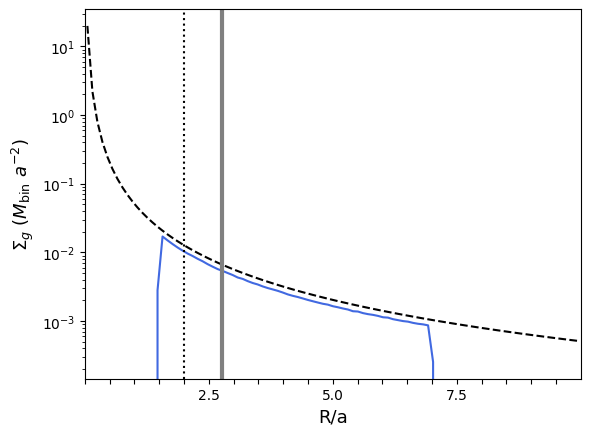

In [4]:
#Binned surface desnity of the gas as a function of normalized radius
def compute_surface_density(gas_coords, masses, BH_coords, BH_masses, a):
    com = np.average(BH_coords, weights=BH_masses, axis=0)
    gas_adj = gas_coords - com
    rad = np.sqrt(gas_adj[:,0]**2 + gas_adj[:,1]**2)
    r_sma = rad / a

    sum_masses, bin_edges, _ = binned_statistic(r_sma, masses, statistic='sum', bins=np.linspace(0,10,100))

    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = bin_edges[:-1] + 0.5 * bin_width
    A = 2 * np.pi * bin_centers * bin_width

    rho = sum_masses / A

    # surface density profile evaluated at bin_centers
    sig_0 = (0.1 * BH_tot) / (2*np.pi * cbd_inner * np.log(7/2))
    alpha = 2
    sigma = sig_0 * (bin_centers * a /cbd_inner)**(-alpha)
    return bin_centers, rho, sigma 


norm = BH_tot / a**2

bc, rho, sigma  = compute_surface_density(gas_coords,  masses,  BH_coords,  BH_masses,  a)
#print(bc)
#bc1, rho1, sigma = compute_surface_density(gas_coords1, masses1, BH_coords1, BH_masses1, a)
#bc2, rho2, sigma = compute_surface_density(gas_coords2, masses2, BH_coords2, BH_masses2, a)
#bc3, rho3, sigma = compute_surface_density(gas_coords3, masses3, BH_coords3, BH_masses3, a)

# Normalize
rho  /= norm
#rho1 /= norm
#rho2 /= norm
#rho3 /= norm
sigma /= norm

fig, ax = plt.subplots()
ax.plot(bc,rho, 'royalblue')
#ax.plot(bc1,rho1, 'royalblue', alpha=0.5)
#ax.plot(bc2,rho2, 'royalblue', alpha=0.7)
#ax.plot(bc3,rho3, 'royalblue')
ax.plot(bc, sigma, ls='--', color='black')
ax.axvline(a, ls=':', color='k')
ax.axvline(2.76, ls='-', color='grey', linewidth=3)
ax.set_xticks(np.arange(0,10, 0.5))
ticks = np.arange(0, 10, 0.5)
ax.set_xticks(ticks)

# Create labels: only show for 2.5, 5, 7.5
labels = [str(t) if t in [2.5, 5, 7.5] else "" for t in ticks]
ax.set_xticklabels(labels)
ax.set_yscale("log")
ax.set_xlim(0,10)
#ax.set_ylim(10e-6,10e-3)
ax.set_xlabel('R/a', fontsize = 13)
ax.set_ylabel(r'$\Sigma_g\ (M_{\rm bin}\ a^{-2})$', fontsize = 13)
#ax.set_ylabel('Surface Density')
#plt.savefig("%s/Surface_dens_norm.png" %plots_dir, bbox_inches="tight",dpi=800)


In [5]:
#print(sum_masses[:])
print(len(r_sma))
z = np.mean(np.absolute(gas_coords[:,2]))/ rad #scale height / radius (?)
print(len(z))

#print(A)
#print(gas_coords)
#print(A)

1000000
1000000


Text(0, 0.5, 'H/R')

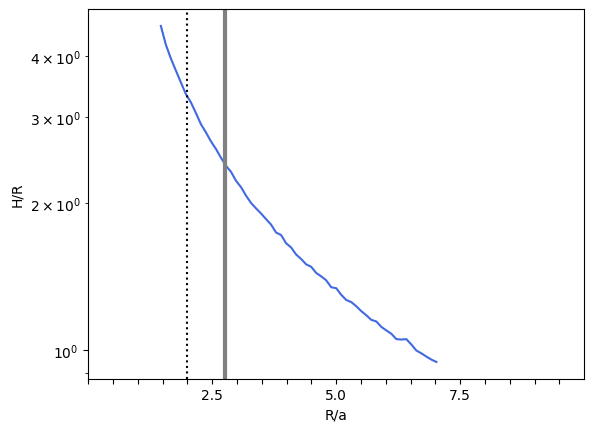

In [6]:
#H/R plot (scale height over radius) (weighted)

def compute_weighted_avg_z(gas_coords, masses, BH_coords, a): 
    com = np.average(BH_coords, weights=BH_masses, axis=0)
    gas_adj = gas_coords - com
    rad = np.sqrt(gas_adj[:,0]**2 + gas_adj[:,1]**2)
    r_sma = rad / a

    z = np.abs(gas_adj[:,2]) #absolute value of only the z component
    
    z_weighted_sum, bin_edges, _ = binned_statistic(r_sma, z * masses, statistic='mean', bins=np.linspace(0,10,100)) #taking mean mass weighted average of absolute of z

    mass_sum, _, _ = binned_statistic(r_sma, masses, statistic='sum', bins=np.linspace(0,10,100)) #sum masses per radial bin

    z_R = z_weighted_sum / mass_sum # This calculates H(R)

    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = bin_edges[:-1] + 0.5 * bin_width
    #A = 2 * np.pi * bin_centers * bin_width

    aspect_ratio = z_weighted_sum / (bin_centers * a) #divide H(R) by R to give H/R for y-axis

    return bin_centers, aspect_ratio

bin_c, H_R = compute_weighted_avg_z(gas_coords, masses, BH_coords, a)
#bin_c1, H_R1 = compute_weighted_avg_z(gas_coords1, masses1, BH_coords1, a)
#bin_c2, H_R2 = compute_weighted_avg_z(gas_coords2, masses2, BH_coords2, a)
#bin_c3, H_R3 = compute_weighted_avg_z(gas_coords3, masses3, BH_coords3, a)


fig, ax = plt.subplots()
ax.plot(bin_c,H_R, 'royalblue')
#ax.plot(bin_c1,H_R1, 'royalblue', alpha=0.5)
#ax.plot(bin_c2,H_R2, 'royalblue', alpha=0.7)
#ax.plot(bin_c3,H_R3, 'royalblue')
ax.axvline(a, ls=':', color='k')
ax.axvline(2.76, ls='-', color='grey', linewidth=3)

ax.set_xlim(0,10)
ax.set_xticks(np.arange(0,10, 0.5))
ticks = np.arange(0, 10, 0.5)
ax.set_yscale("log")
ax.set_xticks(ticks)
labels = [str(t) if t in [2.5, 5, 7.5] else "" for t in ticks]
ax.set_xticklabels(labels)
ax.set_yscale("log")
ax.set_xlim(0,10)
#ax.set_ylim(10e-6,10e-3)
ax.set_xlabel('R/a')
ax.set_ylabel(r'H/R')

#plt.savefig("%s/H_R_plot.png" %plots_dir, bbox_inches="tight",dpi=800)



Text(0, 0.5, 'H/R')

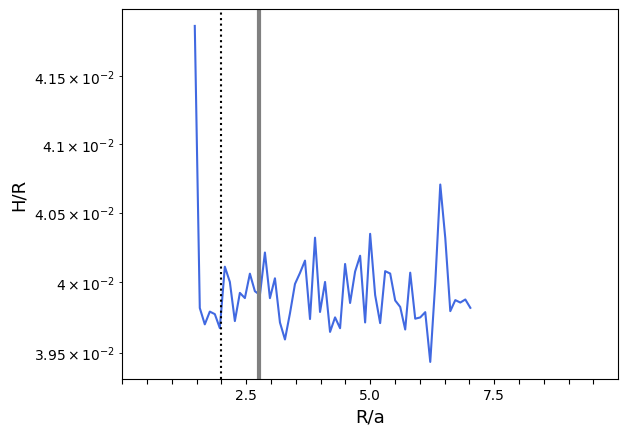

In [7]:
#Unweighted avg
def compute_unweighted_avg_z(gas_coords, masses, BH_coords, a): 
    com = np.average(BH_coords, weights=BH_masses, axis=0)
    gas_adj = gas_coords - com
    rad = np.sqrt(gas_adj[:,0]**2 + gas_adj[:,1]**2)
    r_sma = rad / a

    z = np.abs(gas_adj[:,2]) #absolute value of only the z component
    z_R, bin_edges, _ = binned_statistic(r_sma, np.abs(gas_adj[:,2]), statistic='mean', bins=np.linspace(0,10,100))

    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = bin_edges[:-1] + 0.5 * bin_width

    aspect_ratio = z_R / (bin_centers * a)

    return bin_centers, aspect_ratio

bin_c, H_R = compute_unweighted_avg_z(gas_coords, masses, BH_coords, a)
#bin_c1, H_R1 = compute_unweighted_avg_z(gas_coords1, masses1, BH_coords1, a)
#bin_c2, H_R2 = compute_unweighted_avg_z(gas_coords2, masses2, BH_coords2, a)
#bin_c3, H_R3 = compute_unweighted_avg_z(gas_coords3, masses3, BH_coords3, a)

fig, ax = plt.subplots()
ax.plot(bin_c,H_R, 'royalblue')
#ax.plot(bin_c1,H_R1, 'royalblue', alpha=0.5)
#ax.plot(bin_c2,H_R2, 'royalblue', alpha=0.7)
#ax.plot(bin_c3,H_R3, 'royalblue')
ax.axvline(a, ls=':', color='k')
ax.axvline(2.76, ls='-', color='grey', linewidth=3)

ax.set_xlim(0,10)
ax.set_xticks(np.arange(0,10, 0.5))
ticks = np.arange(0, 10, 0.5)
ax.set_yscale("log")
ax.set_xticks(ticks)
labels = [str(t) if t in [2.5, 5, 7.5] else "" for t in ticks]
ax.set_xticklabels(labels)
ax.set_yscale("log")
ax.set_xlim(0,10)
#ax.set_ylim(10e-6,10e-3)
ax.set_xlabel('R/a', fontsize = 13)
ax.set_ylabel(r'H/R', fontsize = 13)

#plt.savefig("%s/H_R_plot.png" %plots_dir, bbox_inches="tight",dpi=800)


In [8]:
#Plotting Toomre Parameter (Q)
def compute_Q(gas_coords, masses, rho_3d, P, BH_coords, BH_masses, a):
    gamma = 5/3
    G_pc = 4.302e-3  # pc (km/s)^2 / Msun

    #Center of mass
    com = np.average(BH_coords, weights=BH_masses, axis=0)
    gas_adj = gas_coords - com

    #Cylindrical radius
    rad = np.sqrt(gas_adj[:,0]**2 + gas_adj[:,1]**2)
    #rad = np.maximum(rad, 1e-6 * a) # to avoid infinities

    r_sma = rad / a

    #Angular frequency
    M_tot = np.sum(BH_masses) 
    Omega = np.sqrt(G_pc * M_tot / rad**3) #keplerian angular velocity
    kappa = Omega

    #sound speed per particle
    c_s = np.sqrt(gamma * P / rho_3d) * velConversion

    #---Binning---
    #surface density
    sum_masses, bin_edges, _ = binned_statistic(r_sma, masses, statistic='sum', bins=100)

    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = bin_edges[:-1] + 0.5 * bin_width
    A = 2 * np.pi * (bin_centers * a) * (bin_width * a)
    Sigma = sum_masses / A


    #bin c_s and kappa
    c_s_bin, _, _ = binned_statistic(r_sma, c_s, statistic='mean', bins=100)
    kappa_bin, _, _ = binned_statistic(r_sma, kappa, statistic='mean', bins=100)

    #compute Q per bin
    Q_R = (c_s_bin * kappa_bin) / (np.pi * G_pc * Sigma)

    return bin_centers, Q_R


bins, Q_R = compute_Q(gas_coords, masses, rho_3d, P, BH_coords, BH_masses, a)
#bins1, Q_R1 = compute_Q(gas_coords1, masses1, rho_3d1, P1, BH_coords1, BH_masses1, a)
#bins2, Q_R2 = compute_Q(gas_coords2, masses2, rho_3d2, P2, BH_coords2, BH_masses2, a)
#bins3, Q_R3 = compute_Q(gas_coords3, masses3, rho_3d3, P3, BH_coords3, BH_masses3, a)


fig, ax = plt.subplots()
ax.plot(bins,Q_R, 'royalblue', alpha=0.2)
#ax.plot(bins1,Q_R1, 'royalblue', alpha=0.5)
#ax.plot(bins2,Q_R2, 'royalblue', alpha=0.7)
#ax.plot(bins3,Q_R3, 'royalblue')
ax.axvline(a, ls=':', color='k')
ax.axvline(2.76, ls='-', color='grey', linewidth=3)
ax.axhspan(1, 2, xmin=0, xmax=2, color='gray', alpha=0.3)
ax.axhspan(0, 1, xmin=0, xmax=2, color='darkgray', alpha=0.8)


ax.set_xlim(0,10)
ax.set_xticks(np.arange(0,10, 0.5))
ax.set_yticks(np.arange(0, 4, 0.2))
ticks = np.arange(0, 10, 0.5)
ticks1 = np.arange(0, 4, 0.2)
ax.set_xticks(ticks)
labels = [str(t) if t in [2.5, 5, 7.5] else "" for t in ticks]
ax.set_yticks(ticks1)
labels1 = [str(t) if t in [1, 2, 3] else "" for t in ticks1]
ax.set_yticklabels(labels1)
ax.set_xticklabels(labels)
ax.set_ylim(0,4)
ax.set_xlim(0,10)
ax.set_xlabel('R/a', fontsize = 13)
ax.set_ylabel(r'Q', fontsize = 13)

#plt.savefig("%s/Q_plot.png" %plots_dir, bbox_inches="tight",dpi=800)

plt.show()

NameError: name 'rho_3d' is not defined

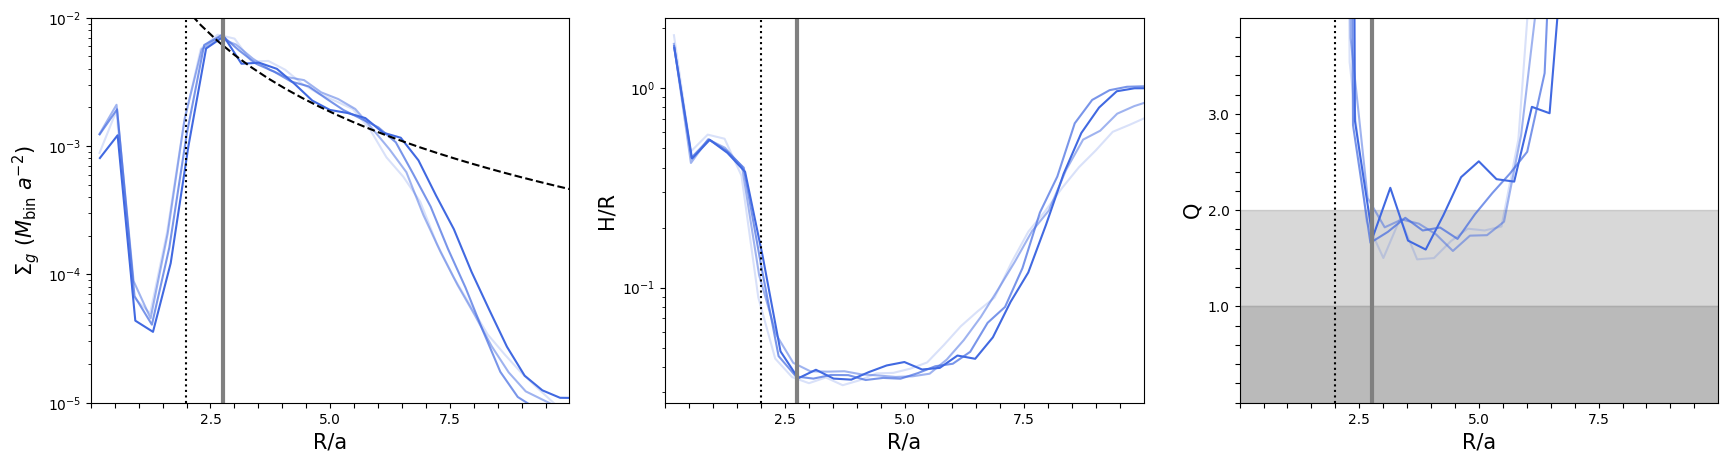

In [ ]:
#combined plots
fig, ax = plt.subplots(1,3, figsize=(21, 5))
#Surface density plot
ax[0].plot(bc,rho, 'royalblue', alpha=0.2)
ax[0].plot(bc1,rho1, 'royalblue', alpha=0.5)
ax[0].plot(bc2,rho2, 'royalblue', alpha=0.7)
ax[0].plot(bc3,rho3, 'royalblue')
ax[0].plot(bc, sigma, ls='--', color='black')
ax[0].axvline(a, ls=':', color='k')
ax[0].axvline(2.76, ls='-', color='grey', linewidth=3)
ax[0].set_xticks(np.arange(0,10, 0.5))
ticks = np.arange(0, 10, 0.5)
ax[0].set_xticks(ticks)

# Create labels: only show for 2.5, 5, 7.5
labels = [str(t) if t in [2.5, 5, 7.5] else "" for t in ticks]
ax[0].set_xticklabels(labels)
ax[0].set_yscale("log")
ax[0].set_xlim(0,10)
ax[0].set_ylim(10e-6,10e-3)
ax[0].set_xlabel('R/a', fontsize = 15)
ax[0].set_ylabel(r'$\Sigma_g\ (M_{\rm bin}\ a^{-2})$', fontsize = 15)

#H/R Plot
ax[1].plot(bin_c,H_R, 'royalblue', alpha=0.2)
ax[1].plot(bin_c1,H_R1, 'royalblue', alpha=0.5)
ax[1].plot(bin_c2,H_R2, 'royalblue', alpha=0.7)
ax[1].plot(bin_c3,H_R3, 'royalblue')
ax[1].axvline(a, ls=':', color='k')
ax[1].axvline(2.76, ls='-', color='grey', linewidth=3)

ax[1].set_xlim(0,10)
ax[1].set_xticks(np.arange(0,10, 0.5))
ticks = np.arange(0, 10, 0.5)
ax[1].set_yscale("log")
ax[1].set_xticks(ticks)
labels = [str(t) if t in [2.5, 5, 7.5] else "" for t in ticks]
ax[1].set_xticklabels(labels)
ax[1].set_yscale("log")
ax[1].set_xlim(0,10)
#ax.set_ylim(10e-6,10e-3)
ax[1].set_xlabel('R/a', fontsize = 15)
ax[1].set_ylabel(r'H/R', fontsize = 15)

#Q plot
ax[2].plot(bins,Q_R, 'royalblue', alpha=0.2)
ax[2].plot(bins1,Q_R1, 'royalblue', alpha=0.5)
ax[2].plot(bins2,Q_R2, 'royalblue', alpha=0.7)
ax[2].plot(bins3,Q_R3, 'royalblue')
ax[2].axvline(a, ls=':', color='k')
ax[2].axvline(2.76, ls='-', color='grey', linewidth=3)
ax[2].axhspan(1, 2, xmin=0, xmax=2, color='gray', alpha=0.3)
ax[2].axhspan(0, 1, xmin=0, xmax=2, color='darkgray', alpha=0.8)


ax[2].set_xlim(0,10)
ax[2].set_xticks(np.arange(0,10, 0.5))
ax[2].set_yticks(np.arange(0, 4, 0.2))
ticks = np.arange(0, 10, 0.5)
ticks1 = np.arange(0, 4, 0.2)
ax[2].set_xticks(ticks)
labels = [str(t) if t in [2.5, 5, 7.5] else "" for t in ticks]
ax[2].set_yticks(ticks1)
labels1 = [str(t) if t in [1, 2, 3] else "" for t in ticks1]
ax[2].set_yticklabels(labels1)
ax[2].set_xticklabels(labels)
ax[2].set_ylim(0,4)
ax[2].set_xlim(0,10)
ax[2].set_xlabel('R/a', fontsize = 15)
ax[2].set_ylabel(r'Q', fontsize = 15)

plt.savefig("%s/CBD_prop_combined.png" %plots_dir, bbox_inches="tight",dpi=800)
